In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
(150, 4)

Training Data: (120, 4)
Testing Data: (30, 4)

Model Training Completed!

Accuracy:
0.9

Accuracy Percentage:
90.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


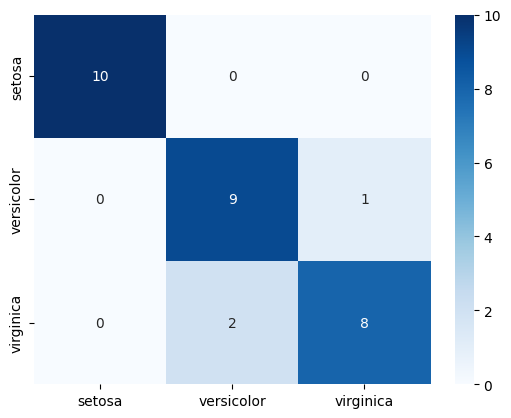


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Feature Importance:
sepal length (cm) : 0.11634850540739942
sepal width (cm) : 0.014999733101994138
petal length (cm) : 0.43146640568097017
petal width (cm) : 0.4371853558096363

New Flower Prediction:
[0]
Predicted Flower: setosa

Prediction Probability:
[[1. 0. 0.]]


In [9]:
# RANDOM FOREST CLASSIFICATION USING IRIS DATASET
# Step 1: Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt


# Step 2: Load Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nDataset Shape:")
print(X.shape)

# Step 3: Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)
# Step 4: Create Random Forest Classifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Step 5: Train the Model

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# Step 6: Make Predictions
y_pred = model.predict(X_test)

# Step 7: Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(accuracy * 100, "%")

# Step 8: Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.show()

# Step 9: Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

# Step 10: Feature Importance
print("\nFeature Importance:")

for feature, importance in zip(
    iris.feature_names,
    model.feature_importances_
):
    print(feature, ":", importance)
# Step 11: Predict a New Flower
# [sepal length, sepal width, petal length, petal width]

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nNew Flower Prediction:")
print(prediction)

print(
    "Predicted Flower:",
    iris.target_names[prediction[0]]
)

# Step 12: Prediction Probability

probability = model.predict_proba(new_flower)

print("\nPrediction Probability:")
print(probability)
